# Week 3 Assignment: Monte Carlo Simulation and Geometric Brownian Motion

## Task 1: Estimating Area Using Monte Carlo Simulation

In [7]:
import numpy as np
import matplotlib.pyplot as plt
N = 500
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)
inside = (x**2 + y**2) <= 1
N_inside = np.sum(inside)
area_estimate = N_inside / N
print(f"Area Estimate (N=500): {area_estimate}")
pi_estimate = area_estimate * 4
print(f"Pi Estimate (N=500): {pi_estimate}")


Area Estimate (N=500): 0.798
Pi Estimate (N=500): 3.192


**(e) Repeat the experiment for N = 500, 1000, 5000, 10000 and comment on how the accuracy changes as N increases.**

*Answer:* As N increases, the estimated value of $\pi$ gets closer to the true value of $\pi$ (approx 3.14159) because of the Law of Large Numbers. The variance of our Monte Carlo estimate decreases as we take more samples.

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_5843/2745072451.py:18: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Monte Carlo $\pi$ Estimation (N={N_plot})")


N =   500 | Pi Estimate = 3.072
N =  1000 | Pi Estimate = 3.108
N =  5000 | Pi Estimate = 3.1376
N = 10000 | Pi Estimate = 3.1804


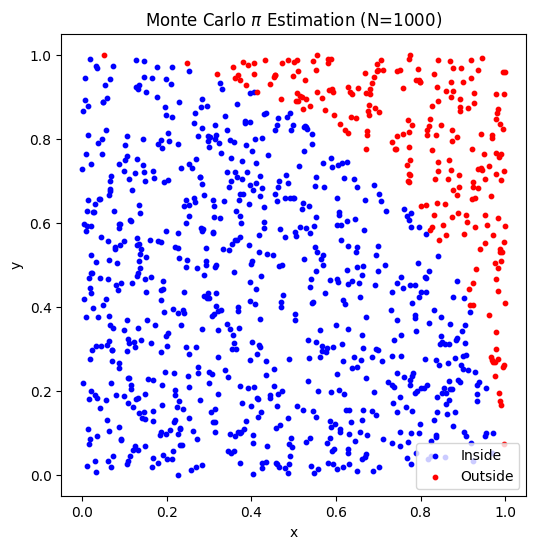

In [2]:
for N in [500, 1000, 5000, 10000]:
    x_n = np.random.uniform(0, 1, N)
    y_n = np.random.uniform(0, 1, N)
    inside_n = (x_n**2 + y_n**2) <= 1
    area_n = np.sum(inside_n) / N
    pi_n = area_n * 4
    print(f"N = {N:5} | Pi Estimate = {pi_n}")

N_plot = 1000
x_p = np.random.uniform(0, 1, N_plot)
y_p = np.random.uniform(0, 1, N_plot)
inside_p = (x_p**2 + y_p**2) <= 1

plt.figure(figsize=(6,6))
plt.scatter(x_p[inside_p], y_p[inside_p], color='blue', label='Inside', s=10)
plt.scatter(x_p[~inside_p], y_p[~inside_p], color='red', label='Outside', s=10)
plt.legend()
plt.title(f"Monte Carlo $\pi$ Estimation (N={N_plot})")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## Task 2: Stock Price Simulation Using Geometric Brownian Motion

**(a) Explain the meaning of the parameters St, $\mu$, $\sigma$, Zt.**

*Answer:*
* **St:** The simulated stock price at time $t$.
* **$\mu$:** The expected return (drift) of the stock per year. It represents the deterministic upward trend.
* **$\sigma$:** The volatility (standard deviation of returns) of the stock per year. It represents the magnitude of the random fluctuations.
* **Zt:** A random variable sampled from a standard normal distribution $N(0,1)$ representing random market shocks at time $t$.

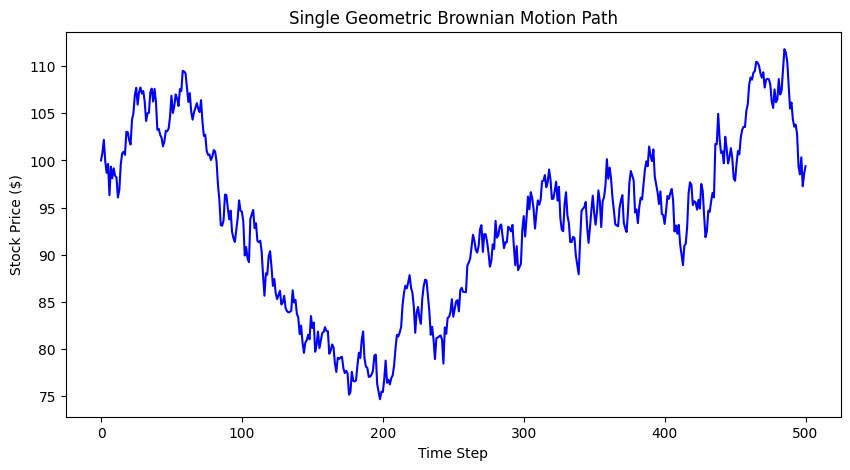

In [3]:
S0 = 100
mu = 0.08
sigma = 0.25
dt = 1/252
steps = 500
path = [S0]
for _ in range(steps):
    Z = np.random.normal(0, 1)
    next_S = path[-1] * np.exp((mu - (sigma**2)/2)*dt + sigma*np.sqrt(dt)*Z)
    path.append(next_S)

plt.figure(figsize=(10, 5))
plt.plot(path, color='blue')
plt.title("Single Geometric Brownian Motion Path")
plt.xlabel("Time Step")
plt.ylabel("Stock Price ($)")
plt.show()


**(g) Briefly explain why different simulations produce different future price paths even though the model parameters remain unchanged.**

*Answer:* Even though the model parameters ($\mu, \sigma$) remain unchanged, each simulation path depends on a sequence of random variables $Z_t$. At each time step, a new random shock is sampled from a standard normal distribution, leading to a unique sequence of price movements for each simulation path. This represents the inherent uncertainty in the stock market.

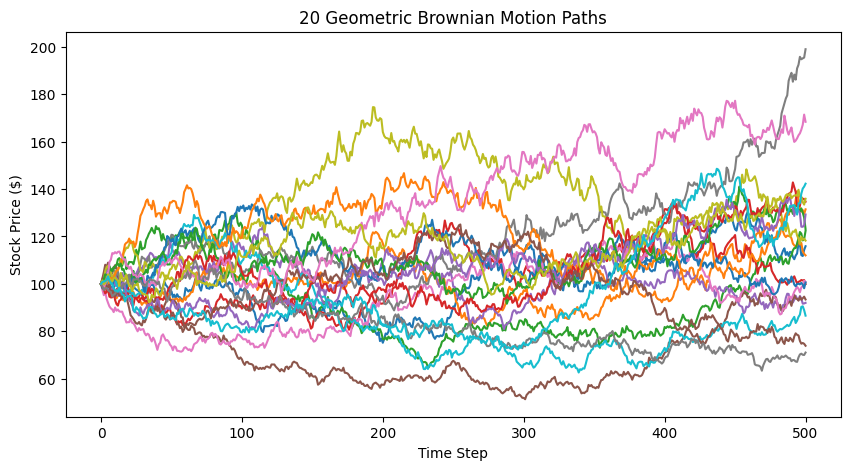

Mean of final prices (20 sims): 117.53
Standard Deviation of final prices (20 sims): 30.02
Estimated Probability P(S_500 > 120): 0.4160


In [4]:
plt.figure(figsize=(10, 5))
final_prices = []

for i in range(20):
    path_i = [S0]
    for _ in range(steps):
        Z = np.random.normal(0, 1)
        next_S = path_i[-1] * np.exp((mu - (sigma**2)/2)*dt + sigma*np.sqrt(dt)*Z)
        path_i.append(next_S)
    plt.plot(path_i)
    final_prices.append(path_i[-1])

plt.title("20 Geometric Brownian Motion Paths")
plt.xlabel("Time Step")
plt.ylabel("Stock Price ($)")
plt.show()
mean_price = np.mean(final_prices)
std_price = np.std(final_prices)
print(f"Mean of final prices (20 sims): {mean_price:.2f}")
print(f"Standard Deviation of final prices (20 sims): {std_price:.2f}")
final_prices_1000 = []
for i in range(1000):
    path_i = [S0]
    for _ in range(steps):
        Z = np.random.normal(0, 1)
        next_S = path_i[-1] * np.exp((mu - (sigma**2)/2)*dt + sigma*np.sqrt(dt)*Z)
        path_i.append(next_S)
    final_prices_1000.append(path_i[-1])
P_greater = np.sum(np.array(final_prices_1000) > 120) / 1000
print(f"Estimated Probability P(S_500 > 120): {P_greater:.4f}")
